In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. Load the file (Make sure the filename matches exactly what's in your Colab sidebar)
file_path = '/4) house Prediction Data Set.csv'
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
# The sep='\s+' handles the spaces between the numbers
df_house = pd.read_csv(file_path, header=None, names=column_names, sep='\s+')

# 2. Preview to make sure it looks right
print(df_house.head())


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3663/2120178103.py:11: SyntaxWarning: invalid escape sequence '\s'
  df_house = pd.read_csv(file_path, header=None, names=column_names, sep='\s+')


In [5]:
# Level 2 - Task 1: Regression Analysis
 ## Goal: Predicting House Prices based on Number of Rooms

Model R-squared: 0.37
Mean Squared Error: 46.14


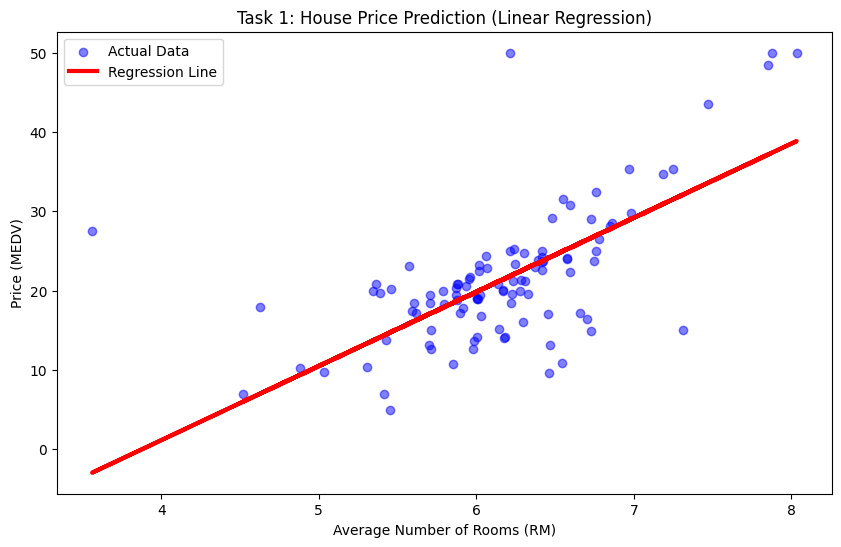

In [4]:
# 1. Define Features (X) and Target (y)
X = df_house[['RM']]
y = df_house['MEDV']

# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Show Evaluation Metrics
print(f"Model R-squared: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")

# 6. Visualize the Results
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=3, label='Regression Line')
plt.title('Task 1: House Price Prediction (Linear Regression)')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Price (MEDV)')
plt.legend()
plt.show()


In [7]:
# Load Iris data
file_path_iris = '/1) iris.csv' # Double check this path matches your sidebar
df_iris = pd.read_csv(file_path_iris)

# If your CSV doesn't have headers, use this instead:
# df_iris = pd.read_csv(file_path_iris, names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])

print(df_iris.head())


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [8]:
# Level 2 - Task 3: Clustering Analysis
## Goal: Grouping Iris Flowers using K-Means Clustering

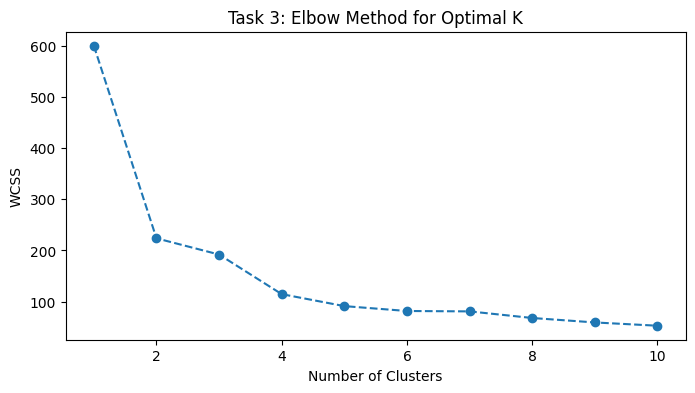

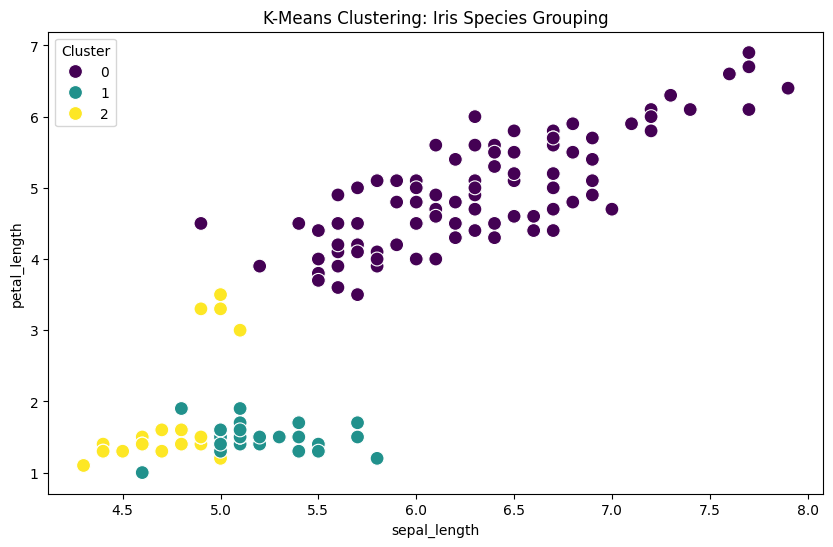

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load the Iris Dataset
# Ensure the path matches the '1) iris.csv' file in your Colab sidebar
df_iris = pd.read_csv('/1) iris.csv')

# 2. Select numerical features for clustering
X = df_iris.iloc[:, :-1]

# 3. Standardize the data (Scaling)
# K-Means relies on distance, so scaling ensures all features contribute equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Use the Elbow Method to find the optimal number of clusters (k)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Task 3: Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# 5. Apply K-Means with 3 clusters (based on the elbow and species count)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df_iris['Cluster'] = kmeans.fit_predict(X_scaled)

# 6. Visualize the Results
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_iris, x=df_iris.columns[0], y=df_iris.columns[2],
                hue='Cluster', palette='viridis', s=100)
plt.title('K-Means Clustering: Iris Species Grouping')
plt.show()
